In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/play-store-dataset/apps.csv
/kaggle/input/play-store-dataset/user_reviews.csv


In [2]:
# Imported all libraries and loaded the csv file for the user review
import pandas as pd 
unique_apps_data = pd.read_csv("/kaggle/input/play-store-dataset/user_reviews.csv")
review_data_file = pd.read_csv("/kaggle/input/play-store-dataset/user_reviews.csv")
review_merge_datafile = pd.merge(unique_apps_data, review_data_file, on='App', how="inner")

review_data_file.head()


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [3]:
review_merge_datafile.head()

,App,Translated_Review_x,Sentiment_x,Sentiment_Polarity_x,Sentiment_Subjectivity_x,Translated_Review_y,Sentiment_y,Sentiment_Polarity_y,Sentiment_Subjectivity_y
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.0,0.533333,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.0,0.533333,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.0,0.533333,NaN,NaN,NaN,NaN
3,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.0,0.533333,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.0,0.533333,Best idea us,Positive,1.00,0.300000


In [4]:
# Imported all libraries and loaded the csv file for the play store apps
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_file = pd.read_csv("/kaggle/input/play-store-dataset/apps.csv")
data_file.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
# Checking for the total amount of apps in the dataset
unique_apps_data = data_file.drop_duplicates(subset = 'App')
print('Total unique apps in the dataset: ', unique_apps_data['App'].nunique())

num_samples = 5
random_sample = unique_apps_data.sample(num_samples)
random_sample

Total unique apps in the dataset:  9659


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1855,2354,Epocrates Plus,MEDICAL,4.3,23889,NaN,"1,000,000+",Free,0,Everyone,Medical,"July 10, 2018",Varies with device,4.0 and up
168,168,eBoox: book reader fb2 epub zip,BOOKS_AND_REFERENCE,4.7,21336,23M,"1,000,000+",Free,0,Everyone,Books & Reference,"June 20, 2018",1.28,3.0 and up
203,203,My Space - Employment Center,BUSINESS,4.5,67000,NaN,"1,000,000+",Free,0,Everyone,Business,"July 17, 2018",Varies with device,4.3 and up
8050,9170,Stickman Legends: Shadow Wars,GAME,4.4,38419,100M,"1,000,000+",Paid,$0.99,Everyone 10+,Action,"August 3, 2018",2.3.24,4.1 and up
8522,9661,EO Bijbel Open,LIFESTYLE,4.3,102,41M,"10,000+",Free,0,Everyone,Lifestyle,"November 24, 2016",2.0.0,4.0.3 and up


In [6]:
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   object 
 6   Installs        9659 non-null   object 
 7   Type            9658 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 1.0+ MB


In [7]:
data_file.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='object')

In [8]:
# Removing string values in the dataframe and converting columns to numeric type
chars_to_remove = [',', '$', '+', 'M', 'k']
cols_to_clean = ['Installs', 'Size', 'Price']

for col in cols_to_clean:
    if unique_apps_data[col].dtype == 'object':
        for char in chars_to_remove:
            unique_apps_data[col] = unique_apps_data[col].str.replace(char, '')
        unique_apps_data[col] = pd.to_numeric(unique_apps_data[col])


In [9]:
# Counting the occurrences of each category in the category column
category_counts = data_file['Category'].value_counts()
category_counts

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
EVENTS                   64
ART_AND_DESIGN           64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [10]:
# Displaying the bar graph which shows the number of apps in each category
import plotly.graph_objs as go
import plotly.offline

number_category = len(unique_apps_data['Category'].unique())
print('Number of categories:', number_category)

num_apps_in_category = unique_apps_data['Category'].value_counts().sort_values(ascending = False)

data_file = [go.Bar(
    x = num_apps_in_category.index,  
    y = num_apps_in_category.values,
    marker = dict(color = 'orange'),  
)]

layout = go.Layout(
    title = 'Number of Play Store Apps in Each Category',
    title_x = 0.5,
    xaxis = dict(title ='Category'),
    yaxis = dict(title ='Number of Play Store Apps'),
    plot_bgcolor = 'black',
)

fig = go.Figure(data = data_file, layout = layout)

plotly.offline.iplot(fig)



Number of categories: 33


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



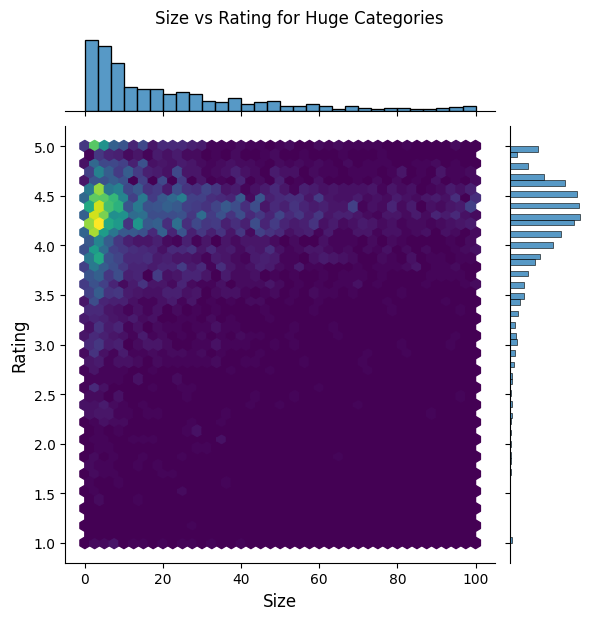

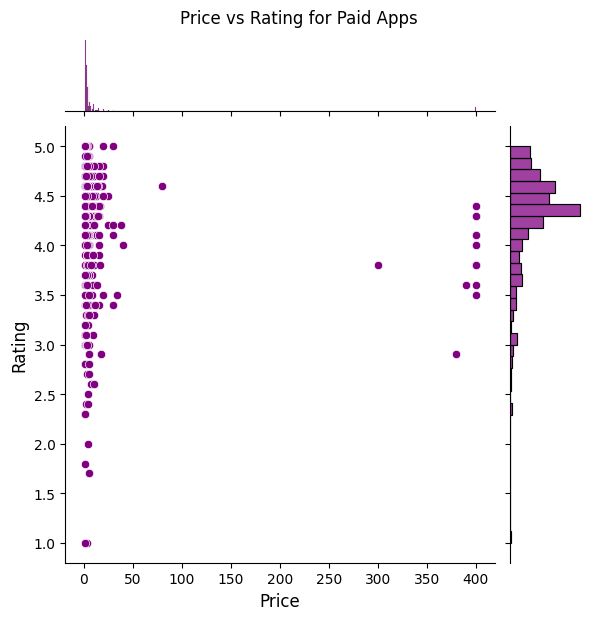

In [11]:
# Displaying a bar graph for Size vs Rating and Price vs Rating
import seaborn as sns
import matplotlib.pyplot as plt

categories = unique_apps_data.groupby('Category').filter(lambda x: len(x) >= 280).reset_index()

plt1 = sns.jointplot(x = categories['Size'], y = categories['Rating'], kind = 'hex', cmap = 'viridis')

paid_apps = unique_apps_data[unique_apps_data['Type'] == 'Paid']

plt2 = sns.jointplot(x = paid_apps['Price'], y = paid_apps['Rating'], color = 'purple')

plt1.set_axis_labels('Size', 'Rating', fontsize = 12)
plt1.fig.suptitle('Size vs Rating for Huge Categories', fontsize = 12, y = 1.02)
plt2.set_axis_labels('Price', 'Rating', fontsize = 12)
plt2.fig.suptitle('Price vs Rating for Paid Apps', fontsize = 12, y = 1.02)

plt.show()


/tmp/ipykernel_18/1717664909.py:8: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




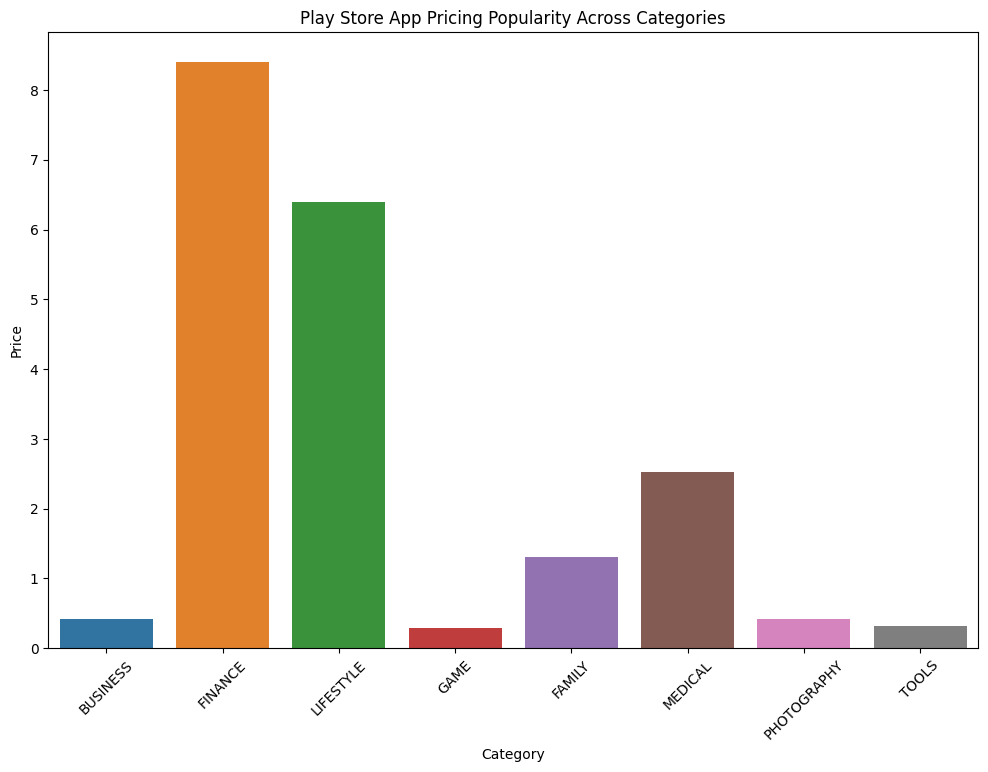

In [12]:
# Displaying the bar graph showing the app pricing popularity across the categories
import matplotlib.pyplot as plt
import seaborn as sns

popular_app_categories = unique_apps_data[unique_apps_data['Category'].isin(['GAME','FAMILY','PHOTOGRAPHY','MEDICAL','TOOLS','FINANCE','LIFESTYLE','BUSINESS'])]

plt.figure(figsize = (12, 8))
sns.barplot(x = 'Category', y = 'Price', data = popular_app_categories, ci = None)
plt.title('Play Store App Pricing Popularity Across Categories')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation = 45)  
plt.show()


In [13]:
# Displaying the box graph of the number he downloads of paid apps vs  free apps
import plotly.graph_objs as go
import plotly.offline

paid_installs = unique_apps_data[unique_apps_data['Type'] == 'Paid']['Installs']
free_installs = unique_apps_data[unique_apps_data['Type'] == 'Free']['Installs']


trace0 = go.Box(
    x=['Paid'] * len(paid_installs),  
    y=paid_installs,
    name='Paid',
    marker=dict(color='#FF00FF'))  

trace1 = go.Box(
    x=['Free'] * len(free_installs),  
    y=free_installs,
    name='Free',
    marker=dict(color='#39FF14'))  

layout = go.Layout(
    title=" The Number of Downloads of Paid Apps vs The Free Apps",
    title_x=0.5,
    yaxis=dict(
        type='log',
        title='Price',
        autorange=True),  
    xaxis=dict(
        title='Paid/Free App'))

data = [trace0, trace1]
plotly.offline.iplot({'data': data, 'layout': layout})

